# Step 1: Creating the synthetic dataset to work on.
The dataset is a 4x2 pixel grid which has a vertical or horizontal line labeled -1 or +1 respectively.

In [82]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

size = 8

vert_size = 2

line_size = 2


def generate_dataset(num_images):
    images = []
    labels = []
    hor_array = np.zeros((size - (line_size - 1) * vert_size, size))
    ver_array = np.zeros((round(size / vert_size) * (vert_size - line_size + 1), size))

    j = 0
    for i in range(0, size - 1):
        if i % (size / vert_size) <= (size / vert_size) - line_size:
            for p in range(0, line_size):
                hor_array[j][i + p] = np.pi / 2
            j += 1

    

    j = 0
    for i in range(0, round(size / vert_size) * (vert_size - line_size + 1)):
        for p in range(0, line_size):
            ver_array[j][i + p * round(size / vert_size)] = np.pi / 2
        j += 1

 

    for n in range(num_images):
        rng = np.random.randint(0, 2)
        if rng == 0:
            labels.append(-1)
            random_image = np.random.randint(0, len(hor_array))
            images.append(np.array(hor_array[random_image]))

        elif rng == 1:
            labels.append(1)
            random_image = np.random.randint(0, len(ver_array))
            images.append(np.array(ver_array[random_image]))
          

        for i in range(size):
            if images[-1][i] == 0:
                images[-1][i] = np.random.rand() * np.pi / 4
    return images, labels


hor_size = round(size / vert_size)





# Splitting the data into training and testing sets (70-30)

In [83]:
np.random.seed(42)
images, labels = generate_dataset(200)

train_images, test_images, train_labels, test_labels = train_test_split(
    images, labels, test_size=0.3, random_state=246
)

# Visualizing to see some of the images created

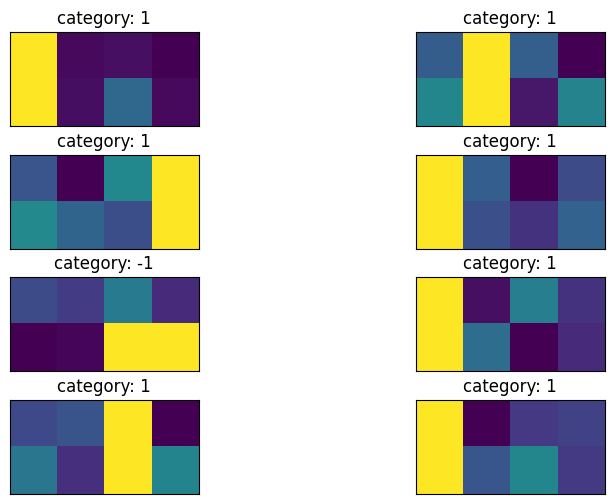

In [84]:


titles = []
for i in range(8):
    title = "category: " + str(train_labels[i])
    titles.append(title)

fig, ax = plt.subplots(4, 2, figsize=(10, 6), subplot_kw={"xticks": [], "yticks": []})

for i in range(8):
    ax[i // 2, i % 2].imshow(
        train_images[i].reshape(vert_size, hor_size),
        aspect="equal",
    )
    ax[i // 2, i % 2].set_title(titles[i])
plt.subplots_adjust(wspace=0.1, hspace=0.3)
plt.show()

# Designing the data encoder circuit

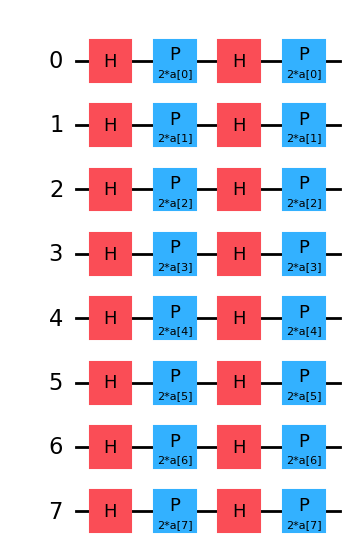

In [85]:
from qiskit.circuit.library import z_feature_map

num_qubits = len(train_images[0])
feature_map = z_feature_map(num_qubits, parameter_prefix="a")

feature_map.draw("mpl")



# Designing the QNN ansatz

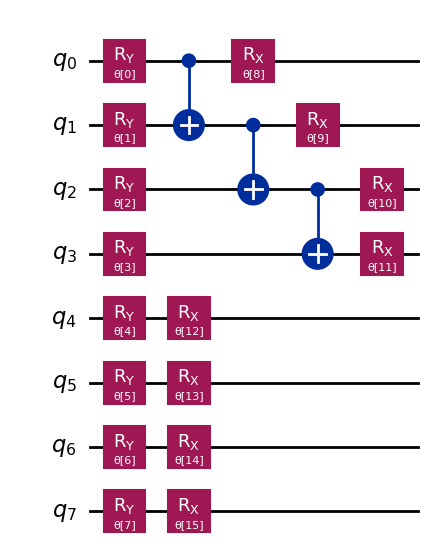

In [86]:
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector


qnn_circuit = QuantumCircuit(size)

params = ParameterVector("θ", length=2 * size)


for i in range(size):
    qnn_circuit.ry(params[i], i)


qnn_cnot_list = [[0, 1], [1, 2], [2, 3]]

for i in range(len(qnn_cnot_list)):
    qnn_circuit.cx(qnn_cnot_list[i][0], qnn_cnot_list[i][1])


for i in range(size):
    qnn_circuit.rx(params[size + i], i)


qnn_circuit.draw("mpl")

# Combining both the Data encoded circuit and ansatz 
This the entire circuit that we will run on the QPU 

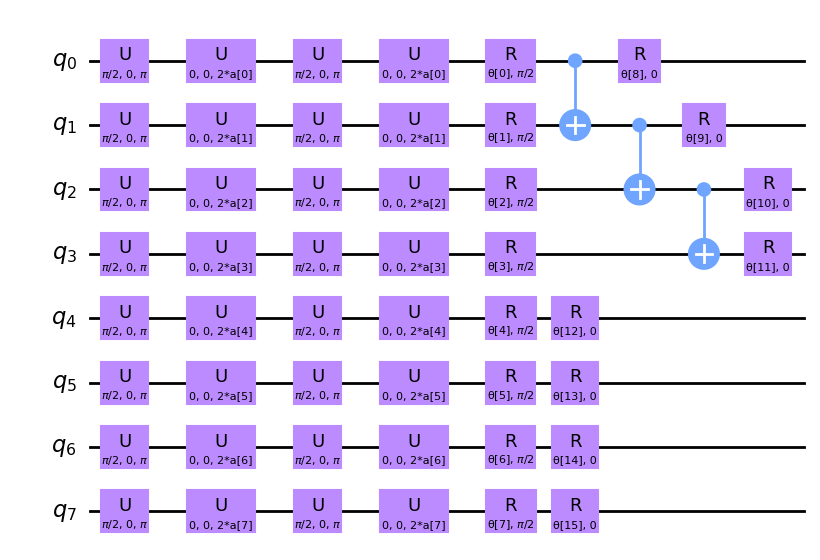

In [87]:
ansatz = qnn_circuit

# Combine the feature map with the ansatz
full_circuit = QuantumCircuit(num_qubits)
full_circuit.compose(feature_map, range(num_qubits), inplace=True)
full_circuit.compose(ansatz, range(num_qubits), inplace=True)

# Display the circuit
full_circuit.decompose().draw("mpl", style="clifford", fold=-1)

# Choosinng an observable
In this case Z (no specific reason) for checking the parity

In [88]:
from qiskit.quantum_info import SparsePauliOp

observable = SparsePauliOp.from_list([("Z" * (num_qubits), 1)])

# Creating the Forward Pass
The forward pass consists of functions that tie all the code together, it takes input parameters and weights as input

In [89]:
from qiskit.primitives import BaseEstimatorV2
from qiskit.quantum_info.operators.base_operator import BaseOperator


def forward(
    circuit: QuantumCircuit,
    input_params: np.ndarray,
    weight_params: np.ndarray,
    estimator: BaseEstimatorV2,
    observable: BaseOperator,
) -> np.ndarray:
    """
    Forward pass of the neural network.

    Args:
        circuit: circuit consisting of data loader gates and the neural network ansatz.
        input_params: data encoding parameters.
        weight_params: neural network ansatz parameters.
        estimator: EstimatorV2 primitive.
        observable: a single observable to compute the expectation over.

    Returns:
        expectation_values: an array (for one observable) or a matrix (for a sequence of observables) of expectation values.
        Rows correspond to observables and columns to data samples.
    """
    num_samples = input_params.shape[0]
    weights = np.broadcast_to(weight_params, (num_samples, len(weight_params)))
    params = np.concatenate((input_params, weights), axis=1)
    pub = (circuit, observable, params)
    job = estimator.run([pub])
    result = job.result()[0]
    expectation_values = result.data.evs

    return expectation_values

# Loss Function

In [90]:
def mse_loss(predict: np.ndarray, target: np.ndarray) -> np.ndarray:
    """
    Mean squared error (MSE).

    prediction: predictions from the forward pass of neural network.
    target: true labels.

    output: MSE loss.
    """
    if len(predict.shape) <= 1:
        return ((predict - target) ** 2).mean()
    else:
        raise AssertionError("input should be 1d-array")

In [91]:
def mse_loss_weights(weight_params: np.ndarray) -> np.ndarray:
    """
    Cost function for the optimizer to update the ansatz parameters.

    weight_params: ansatz parameters to be updated by the optimizer.

    output: MSE loss.
    """
    predictions = forward(
        circuit=circuit,
        input_params=input_params,
        weight_params=weight_params,
        estimator=estimator,
        observable=observable,
    )

    cost = mse_loss(predict=predictions, target=target)
    objective_func_vals.append(cost)

    global iter
    if iter % 50 == 0:
        print(f"Iter: {iter}, loss: {cost}")
    iter += 1

    return cost

In [92]:
from scipy.optimize import minimize

In [93]:
# Globals
circuit = full_circuit
observables = observable
#input_params = train_images_batch 
# target = train_labels_batch
objective_func_vals = []
iter = 0

# Choosing a backend
In this case we choose a backend with the least queue

In [94]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Paste your IBM Quantum API key below
api_key = "8scr5XCZsdb730Aq118MJpWddGSN1TGWXgVqNIfIg_ia"
service = QiskitRuntimeService(token=api_key)
backend = service.least_busy(operational=True, simulator=False)
print(backend.name)

qiskit_runtime_service._discover_account:WARNING:2026-04-09 21:16:38,932: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-04-09 21:16:42,648: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-09 21:16:43,406: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-09 21:16:46,807: Using instance: open-instance, plan: open


ibm_fez


# Optimizing the circuit
We use Dynamic decoupling

In [95]:
from qiskit.circuit.library import XGate
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import (
    ALAPScheduleAnalysis,
    ConstrainedReschedule,
    PadDynamicalDecoupling,
)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target

pm = generate_preset_pass_manager(target=target, optimization_level=3)
pm.scheduling = PassManager(
    [
        ALAPScheduleAnalysis(target=target),
        ConstrainedReschedule(
            acquire_alignment=target.acquire_alignment,
            pulse_alignment=target.pulse_alignment,
            target=target,
        ),
        PadDynamicalDecoupling(
            target=target,
            dd_sequence=[XGate(), XGate()],
            pulse_alignment=target.pulse_alignment,
        ),
    ]
)

In [96]:
circuit_ibm = pm.run(full_circuit)
observable_ibm = observable.apply_layout(circuit_ibm.layout)

# Big Picture
We connect everything and attach it with a classical optimizer for training the model by updating the weights

In [97]:
from qiskit.primitives import StatevectorEstimator as Estimator

batch_size = 140
num_epochs = 1
num_samples = len(train_images)

# Globals
circuit = full_circuit
estimator = Estimator()  # simulator for debugging
observables = observable
objective_func_vals = []
iter = 0

# Random initial weights for the ansatz
np.random.seed(42)
weight_params = np.random.rand(len(ansatz.parameters)) * 2 * np.pi

for epoch in range(num_epochs):
    for i in range((num_samples - 1) // batch_size + 1):
        print(f"Epoch: {epoch}, batch: {i}")
        start_i = i * batch_size
        end_i = start_i + batch_size
        train_images_batch = np.array(train_images[start_i:end_i])
        train_labels_batch = np.array(train_labels[start_i:end_i])
        input_params = train_images_batch
        target = train_labels_batch
        iter = 0
        res = minimize(
            mse_loss_weights, weight_params, method="COBYLA", options={"maxiter": 100}
        )
        weight_params = res["x"]

Epoch: 0, batch: 0
Iter: 0, loss: 1.0002309063537163
Iter: 50, loss: 0.9910034423915833


# Testing and Accuracy
Running the circuit on actual Quantum backend

In [ ]:
import copy
from sklearn.metrics import accuracy_score
from qiskit.primitives import StatevectorEstimator as SimEstimator  # simulator
from qiskit_ibm_runtime import EstimatorV2  # real quantum computer

# EstimatorV2 in this runtime version uses the 'mode' argument
estimator = EstimatorV2(mode=backend)

# Run only the transpiled IBM circuit on the IBM primitive
pred_train = forward(circuit_ibm, np.array(train_images), res['x'], estimator, observable_ibm)

print(pred_train)

pred_train_labels = copy.deepcopy(pred_train)
pred_train_labels[pred_train_labels >= 0] = 1
pred_train_labels[pred_train_labels < 0] = -1
print(pred_train_labels)
print(train_labels)

accuracy = accuracy_score(train_labels, pred_train_labels)
print(f"Train accuracy: {accuracy * 100}%")


IBMInputValueError: 'The instruction h on qubits (0,) is not supported by the target system. Circuits that do not match the target hardware definition are no longer supported after March 4, 2024. See the transpilation documentation (https://quantum.cloud.ibm.com/docs/guides/transpile) for instructions to transform circuits and the primitive examples (https://quantum.cloud.ibm.com/docs/guides/primitives-examples) to see this coupled with operator transformations.'